In [2]:
# ============================================================
# TRANSFORMER FOR MODERN AI
# PART-1A : DATA LOADING & BASIC INSPECTION
# CPU FRIENDLY
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.datasets import imdb


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

VOCAB_SIZE = 5000

TRAIN_SIZE = 5000
TEST_SIZE = 1000


# ------------------------------------------------------------
# Load IMDb Dataset
# ------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)


# ------------------------------------------------------------
# Reduce Dataset for Slow CPU
# ------------------------------------------------------------

X_train = X_train[:TRAIN_SIZE]
y_train = y_train[:TRAIN_SIZE]

X_test = X_test[:TEST_SIZE]
y_test = y_test[:TEST_SIZE]


# ------------------------------------------------------------
# Convert Labels
# ------------------------------------------------------------

y_train = np.array(
    y_train,
    dtype=np.float32
)

y_test = np.array(
    y_test,
    dtype=np.float32
)


# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("=" * 60)
print("TRANSFORMER NLP PROJECT - PART-1A")
print("=" * 60)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("Vocabulary Size  :", VOCAB_SIZE)

print("\nFirst Review Length :", len(X_train[0]))
print("First Review Label  :", int(y_train[0]))

print("\nLabel Meaning:")
print("0 = Negative")
print("1 = Positive")


# ------------------------------------------------------------
# Check Review Lengths
# ------------------------------------------------------------

train_lengths = [
    len(review)
    for review in X_train
]

print("\n")
print("Average Review Length :",
      round(np.mean(train_lengths), 2))

print("Maximum Review Length :",
      max(train_lengths))

print("Minimum Review Length :",
      min(train_lengths))




TRANSFORMER NLP PROJECT - PART-1A
Training Samples : 5000
Testing Samples  : 1000
Vocabulary Size  : 5000

First Review Length : 218
First Review Label  : 1

Label Meaning:
0 = Negative
1 = Positive


Average Review Length : 243.82
Maximum Review Length : 1851
Minimum Review Length : 16


In [3]:
# ============================================================
# TRANSFORMER FOR MODERN AI
# PART-1B : PADDING & DATA PREPARATION
# CPU FRIENDLY
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

MAX_LENGTH = 100
BATCH_SIZE = 32


# ------------------------------------------------------------
# Padding / Truncating Reviews
# ------------------------------------------------------------

X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)


# ------------------------------------------------------------
# Convert to int32 for CPU efficiency
# ------------------------------------------------------------

X_train = X_train.astype(np.int32)
X_test = X_test.astype(np.int32)


# ------------------------------------------------------------
# Create TensorFlow Datasets
# ------------------------------------------------------------

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)


test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)


# ------------------------------------------------------------
# Check
# ------------------------------------------------------------



In [4]:
# ============================================================
# TRANSFORMER FOR MODERN AI
# PART-2 : TRANSFORMER MODEL & TRAINING
# CPU FRIENDLY
# ============================================================

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 64


# ------------------------------------------------------------
# Transformer Encoder
# ------------------------------------------------------------

inputs = layers.Input(
    shape=(MAX_LENGTH,),
    dtype="int32"
)

embedding = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM
)(inputs)

attention = layers.MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM // NUM_HEADS
)(
    embedding,
    embedding
)

x = layers.Add()([
    embedding,
    attention
])

x = layers.LayerNormalization()(x)

ff = layers.Dense(
    FF_DIM,
    activation="relu"
)(x)

ff = layers.Dense(
    EMBED_DIM
)(ff)

x = layers.Add()([
    x,
    ff
])

x = layers.LayerNormalization()(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(
    16,
    activation="relu"
)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model = Model(
    inputs,
    outputs
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)


# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    test_dataset,
    verbose=0
)




print("Test Loss     :", round(float(loss), 4))
print("Test Accuracy :", round(float(accuracy), 4))

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.6836 - loss: 0.5879 - val_accuracy: 0.7740 - val_loss: 0.4651
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8396 - loss: 0.3604 - val_accuracy: 0.7870 - val_loss: 0.4911
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8978 - loss: 0.2508 - val_accuracy: 0.7770 - val_loss: 0.6012
Test Loss     : 0.4651
Test Accuracy : 0.774


MODEL EVALUATION
Test Loss     : 0.4651
Test Accuracy : 0.774


SAMPLE PREDICTIONS


,Actual,Predicted,Probability
0,0,0,0.164
1,1,1,0.919
2,1,1,0.813
3,0,0,0.106
4,1,1,0.580
5,1,0,0.401
6,1,0,0.469
7,0,1,0.679
8,0,1,0.918
9,1,0,0.281


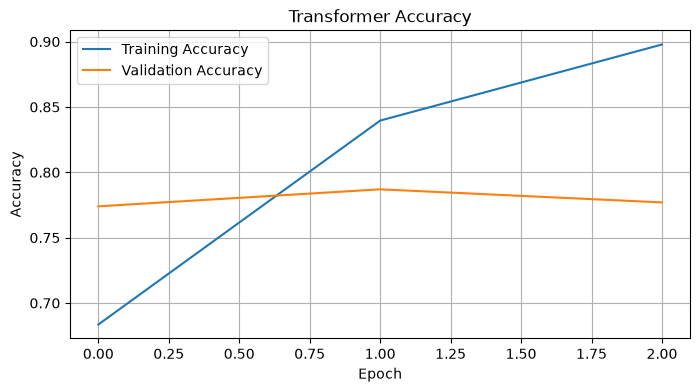

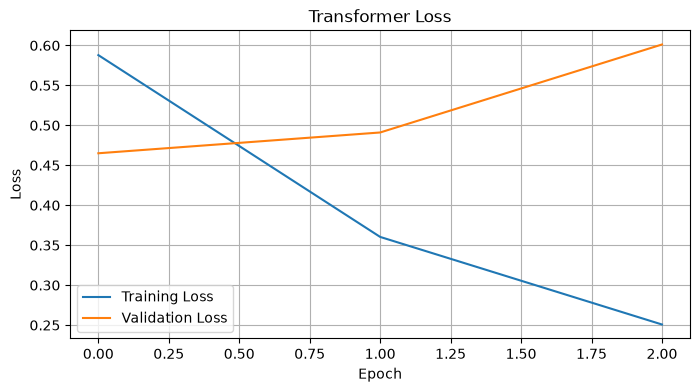



TRANSFORMER PROJECT COMPLETED
Dataset        : IMDb Reviews
Model          : Transformer Encoder
Embedding Size : 32
Attention Heads: 2
Sequence Length: 100
Test Accuracy  : 0.774

Saved Files:
transformer_nlp_model.keras
transformer_predictions.csv


In [5]:
# ============================================================
# TRANSFORMER FOR MODERN AI
# PART-3 : EVALUATION & PREDICTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Evaluate Model
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    test_dataset,
    verbose=0
)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Test Loss     :", round(float(loss), 4))
print("Test Accuracy :", round(float(accuracy), 4))


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

predictions = model.predict(
    X_test,
    verbose=0
).flatten()

predicted_labels = (
    predictions >= 0.5
).astype(int)


# ------------------------------------------------------------
# Prediction Results
# ------------------------------------------------------------

results = pd.DataFrame({

    "Actual": y_test.astype(int),

    "Predicted": predicted_labels,

    "Probability": np.round(
        predictions,
        3
    )

})

print("\n")
print("=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

display(
    results.head(10)
)


# ------------------------------------------------------------
# Accuracy Graph
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Transformer Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# Loss Graph
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Transformer Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()


# ------------------------------------------------------------
# Save Model
# ------------------------------------------------------------

model.save(
    "transformer_nlp_model.keras"
)


# ------------------------------------------------------------
# Save Predictions
# ------------------------------------------------------------

results.to_csv(
    "transformer_predictions.csv",
    index=False
)


# ------------------------------------------------------------
# Final Summary
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("TRANSFORMER PROJECT COMPLETED")
print("=" * 60)

print("Dataset        : IMDb Reviews")
print("Model          : Transformer Encoder")
print("Embedding Size :", EMBED_DIM)
print("Attention Heads:", NUM_HEADS)
print("Sequence Length:", MAX_LENGTH)
print("Test Accuracy  :", round(float(accuracy), 4))

print("\nSaved Files:")
print("transformer_nlp_model.keras")
print("transformer_predictions.csv")

print("=" * 60)